In [1]:
using Catalyst: spatial_convert_err
include("../src/DiscreteStochasticSimulation.jl")
#include("../src/core/ssa.jl")
using .DiscreteStochasticSimulation
using Catalyst
using ProgressMeter 
ProgressMeter.ijulia_behavior(:clear)
using Plots
using Expokit
using SparseArrays
using DifferentialEquations 
using LaTeXStrings
using OrdinaryDiffEq
using Interpolations
using Statistics
using JLD

┌ Warning: Replacing docs for `Main.DiscreteStochasticSimulation.FindLowestValuesPercent :: Union{Tuple{T}, Tuple{Vector{T}, Number}} where T` in module `Main.DiscreteStochasticSimulation`
└ @ Base.Docs docs/Docs.jl:243


## Lotka Volterra Chemical Reaction Network Definition using Catalyst.jl DSL

In [2]:
# Create model.
rn = @reaction_network begin
    kB, S + E --> SE
    kD, SE --> S + E
    kP, SE --> P + E
end

Model ##ReactionSystem#236
Unknowns (4):
  S(t)
  E(t)
  SE(t)
  P(t)
Parameters (3):
  kB
  kD
  kP

## Plug in the reaction network structure into the discrete system wrapper

In [3]:
model = DiscreteStochasticSystem(rn);

## Define boundary condition function

Rectangular lattice simply means the solver won't consider states beyond the limits

In [4]:
 # define boundaries (rectangular lattice in this case)
bounds = (0, 60) #(lower limit, upper limit)
boundary_condition(x) = RectLatticeBoundaryCondition(x, bounds);

## Define initial state and place it in a set, then expand the space 

In [5]:
# define initial value and expand the space a bit 
U₀ = CartesianIndex(50, 10, 1, 1);

## Define a probability density vector over the initial state space and set the probability of initial value to 1 (rest to zero)

In [6]:
δt = 0.1
T = 0:δt:200
rates=[0.01, 0.1, 0.1];

In [7]:
X = Set([U₀])
X = Expand!(X, model, rates, 0.0, boundary_condition, 3);

## Run the simulation (sliding windows algorithm for fiite state projection)

In [9]:
# definine initial state set 
X = Set([U₀])
X = Expand!(X, model, boundary_condition, 50);

# initial probability vector (only for active states)
p₀ = zeros(X |> length)
p₀[DiscreteStochasticSimulation.FindElement(U₀, X)] = 1

global iter = 1
global pₜ = p₀
global sz = []
global m =[]

# time intrerval 
sol = []
global p = Progress(length(T))

for t ∈ T
    #expand space and assemble matrix
    global X, pₜ = Expand!(X, pₜ, model, rates, 0.0, boundary_condition, 2)

    push!(sz, length(X))

    A = MasterEquation(X, model, [0.01, 0.1, 0.1], boundary_condition, δt)
    # solve system and normalize (using expokit (can also use numerical time steppers such as Runge-Kutta))
    global pₜ = expmv(δt, A, pₜ)
    push!(sol, (X, pₜ))

    # purge lowest 80% probability states (most will be zero; this is arbitrary as of now)
    X, pₜ = Purge!(X, pₜ, 0.001)
    push!(m, 1.0 - sum(pₜ) + sum(abs.(pₜ .- (pₜ ./ sum(pₜ)))))
    pₜ ./= sum(pₜ) # re-normalize the reduced state space

    # sparse matrix 
    iter+=1

    # comment following line if not using progress meter
    # comment following line if not using progress meter
    next!(p; showvalues = [
                           ("time (t)", t),
                           ("system size",sz[end]),
                           (" ", " "), 
                           ("system size (after purge)",length(pₜ)),
                           ("num pruned states", sz[end]-length(pₜ)),
                           ("pruned mass", m[end])])
    
end
#@save "sol_10_29.jld" sol

Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
  time (t):                   200.0
  system size:                15
   :                           
  system size (after purge):  14
  num pruned states:          1
  pruned mass:                2.5204421524735254e-7


# Calculate FSP mean trajectory

In [10]:
sol_mean = @showprogress map(1:length(T)) do i
    sum(collect.(Tuple.(sol[i][1])) .* sol[i][2])
end 
fsp_mean=hcat(sol_mean...)'

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


2001×4 adjoint(::Matrix{Float64}) with eltype Float64:
 49.5734   9.5755   1.4245    1.00215
 49.1738   9.18219  1.81781   1.00835
 48.7992   8.81749  2.18251   1.01825
 48.4475   8.47902  2.52098   1.03148
 48.117    8.1648   2.8352    1.04783
 47.8058   7.87293  3.12707   1.06712
 47.5126   7.60162  3.39838   1.08907
 47.2359   7.34993  3.65007   1.11405
 46.9745   7.1159   3.8841    1.1414
 46.7272   6.89815  4.10185   1.17091
 46.4931   6.69545  4.30455   1.20238
 46.271    6.50666  4.49334   1.23566
 46.0601   6.33089  4.66911   1.27076
  ⋮                          
  1.17257  9.90728  1.09272  49.7347
  1.17196  9.9076   1.0924   49.7356
  1.17136  9.90792  1.09208  49.7366
  1.17076  9.90823  1.09177  49.7375
  1.17016  9.90855  1.09145  49.7384
  1.16956  9.90887  1.09113  49.7393
  1.16896  9.90918  1.09082  49.7402
  1.16837  9.9095   1.0905   49.7411
  1.16778  9.90981  1.09019  49.742
  1.16719  9.91012  1.08988  49.7429
  1.1666   9.91043  1.08957  49.7438
  1.16602  9.910

# SSA solution

In [11]:
using JumpProcesses

# Create an ODE that can be simulated.
u0_integers = [:S => 50, :E => 10, :SE => 1, :P => 1]
tspan = (0., 200.)
ps = [:kB => 0.01, :kD => 0.1, :kP => 0.1]

jinput = JumpInputs(rn, u0_integers, tspan, ps)
jprob = JumpProblem(jinput)
jump_sol = solve(jprob)

n_trajs = 1000
ssa_trajs1=[]
@showprogress for i in 1:n_trajs 
    push!(ssa_trajs1, solve(jprob, SSAStepper()))
end;

## Mean SSA Trajectory 

In [12]:
uniform_time, ssa_mean = mean_trajectory(ssa_trajs1, T[1], T[end], length(T))

(LinRange{Float64}(0.0, 200.0, 2001), [49.9999999999993 9.999999999999831 1.0000000000000007 1.0000000000000007; 49.19483271696807 9.213309339577828 1.7866906604221664 1.0184766226097646; … ; 0.03900000000000003 10.956999999999852 0.04300000000000003 51.91799999999969; 0.03900000000000003 10.956999999999852 0.04300000000000003 51.91799999999969])

In [12]:
uniform_time

2001-element LinRange{Float64, Int64}:
 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, …, 199.6, 199.7, 199.8, 199.9, 200.0

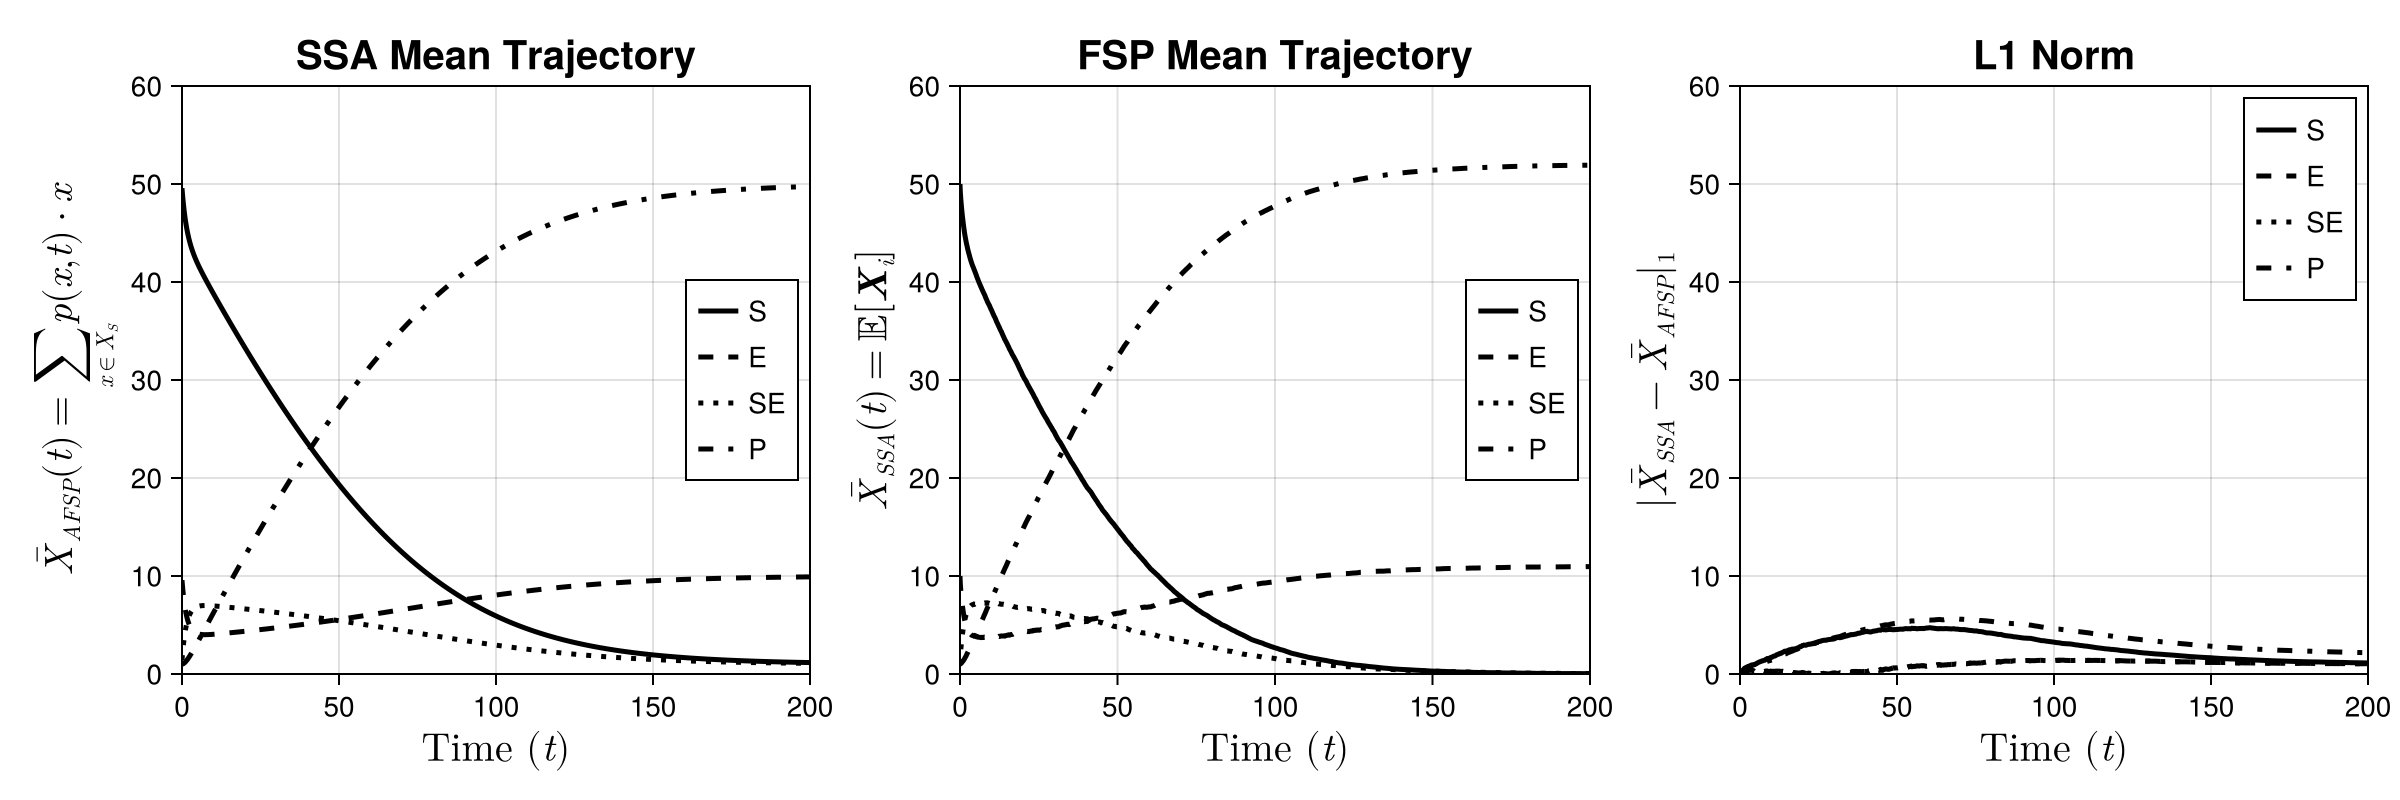

In [23]:
using CairoMakie

# Sample data: large 1000×4 matrix
n = length(T)  # Number of points
data1 = ssa_mean  # First dataset
data2 = fsp_mean  # Second dataset
data3 = abs.(fsp_mean .- ssa_mean) 
fig = Figure(size=(1200, 400))  # Set figure size

xlabel_size=20
ylabel_size=20
title_size = 20

# Create two subplots
ax2 = Axis(fig[1, 1], xlabel = L"Time $(t)$", ylabel = L"$\bar{X}_{AFSP}(t)=\sum_{x \in X_S}p(x, t) \cdot x$", title = "SSA Mean Trajectory", titlesize=title_size,xlabelsize=xlabel_size, ylabelsize=ylabel_size)
ax1 = Axis(fig[1, 2], xlabel = L"Time $(t)$", ylabel = L"$\bar{X}_{SSA}(t)=\mathbb{E}\left[\mathbf{X}_i\right]$", title = "FSP Mean Trajectory", titlesize=title_size, xlabelsize=xlabel_size, ylabelsize=ylabel_size)
ax3 = Axis(fig[1, 3], xlabel = L"Time $(t)$", ylabel = L"|\bar{X}_{SSA} - \bar{X}_{AFSP}|_1", title = "L1 Norm", titlesize=title_size,xlabelsize=xlabel_size, ylabelsize=ylabel_size)

CairoMakie.ylims!(ax1, 0,60) 
CairoMakie.ylims!(ax2, 0, 60) 
CairoMakie.ylims!(ax3, 0, 60) 
CairoMakie.xlims!(ax1, 0,200) 
CairoMakie.xlims!(ax2, 0, 200) 
CairoMakie.xlims!(ax3, 0, 200) 

linestyles = [:solid, :dash, :dot, :dashdot]     # Different line styles
labels = ["S", "E", "SE", "P"]

# Choose marker frequency (plot markers only at these indices)
marker_step = 20
marker_indices = 1:marker_step:n

# Function to plot on a given axis
function plot_data!(ax, data; position = :rc)
    for i in 1:4
        # 1) Thin lines
        CairoMakie.lines!(ax, uniform_time, data[:, i];
            color     = :black,
            linestyle = linestyles[i],
            linewidth = 2.5,  # Thin lines
            label     = labels[i]
        )
    end
    axislegend(ax, position = position)  # Add legend
end

# Plot data in both subplots
default(xticklabelsize=20)
plot_data!(ax1, data1)
plot_data!(ax2, data2)
plot_data!(ax3, data3, position=:rt)

save("mm.pdf", fig)
fig  # Display the figure


In [15]:
ssa_mean = zeros(length(T), length(ssa_trajs1[1].u[1]))
@showprogress for i in 1:length(T)-2
    for (j, traj) in enumerate(ssa_trajs1)
        idxs = findall( (traj.t .>= T[i]) .& (traj.t .< T[i+1])) 
        if length(idxs) > 0
            ssa_mean[i, :] .+= sum(traj.u[idxs]) ./ length(idxs)
        end
    end
    ssa_mean[i, :] ./= length(ssa_trajs1)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:20


In [14]:
using JLD
@save "mm_err.jld" m sz


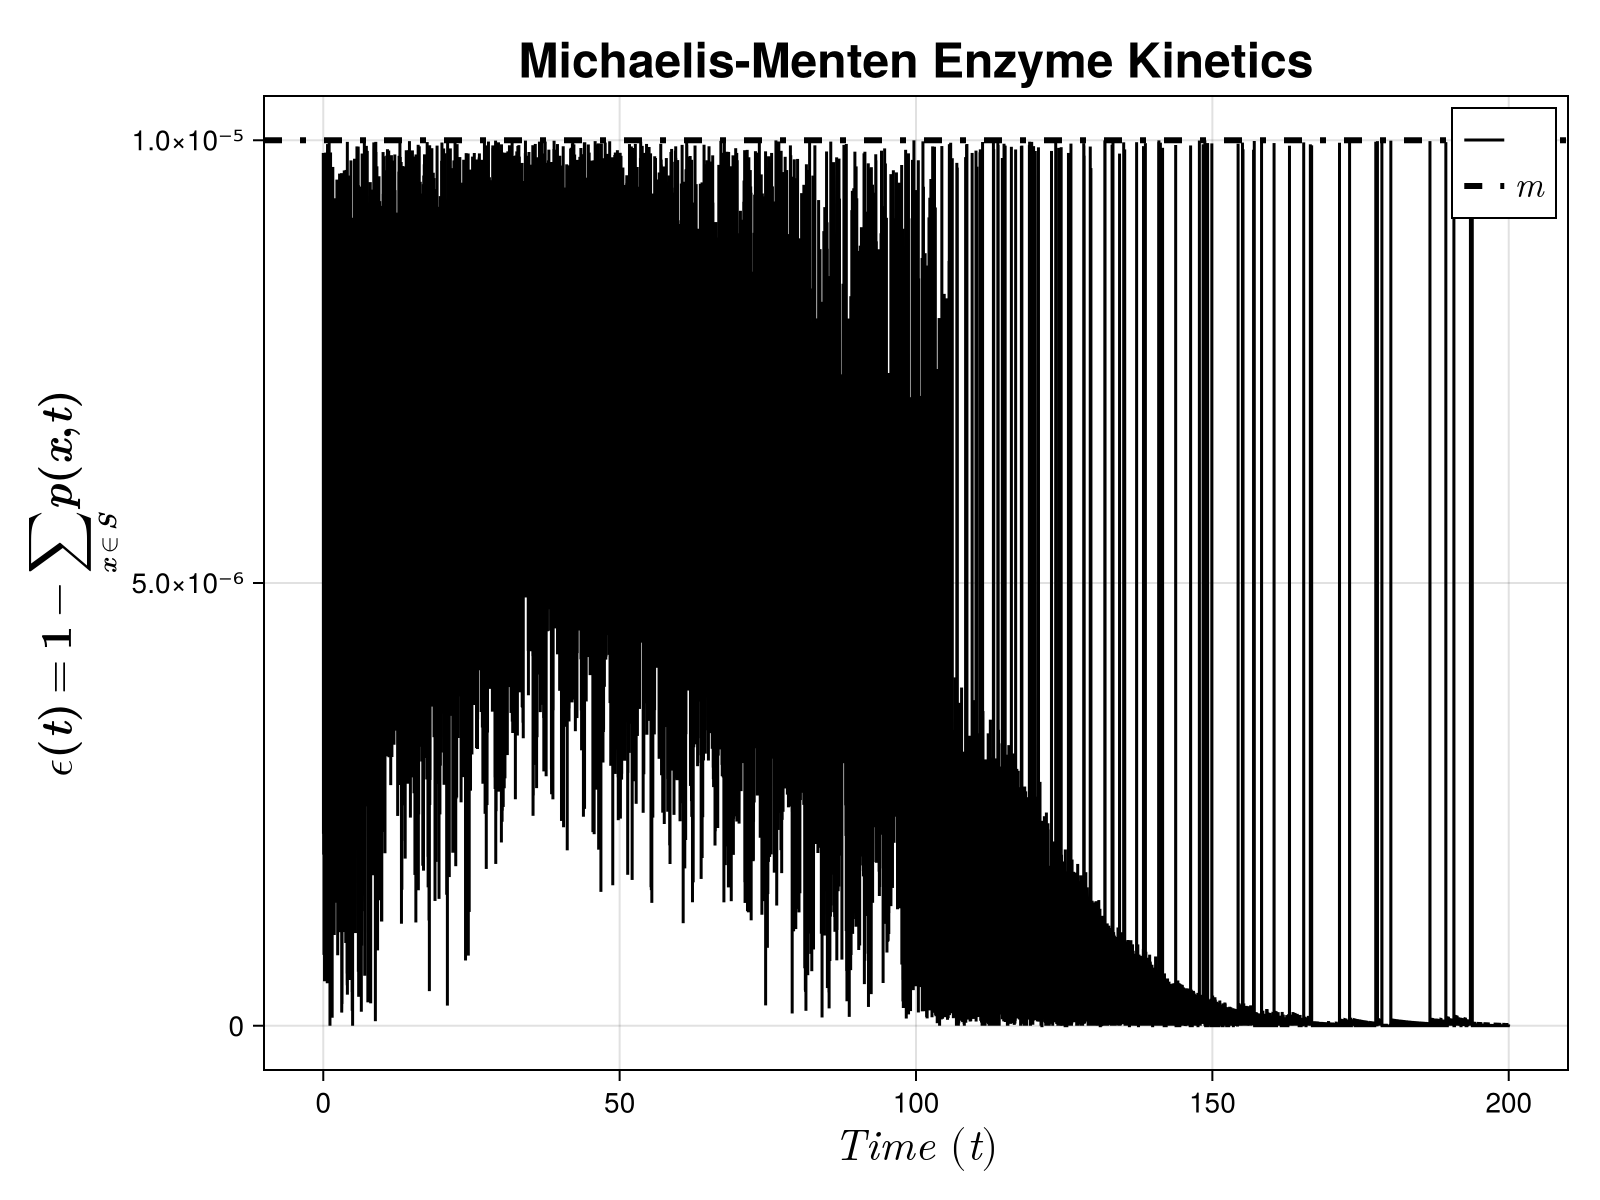

CairoMakie.Screen{IMAGE}


In [118]:
using CairoMakie, LaTeXStrings

fig = Figure(size=(800, 600))

ax = Axis(fig[1, 1],
    title="Michaelis-Menten Enzyme Kinetics",
    xlabel=L"Time\ (t)",
    ylabel=L"\mathbf{\epsilon(t) = 1 - \sum_{x \in S} p(x, t)}",
    xlabelsize=22, ylabelsize=22, titlesize=24
)

lines!(T, m, color=:black, label="")  # Main line plot

hlines!([1e-5], color=:black, linestyle=:dashdot, linewidth=3, label=L"$m$")  # Dashed horizontal line

axislegend(ax, position=:rt, labelsize=18)  # Show legend with larger font

save("lv_err.pdf", fig)  # Save the figure
display(fig)  # Display the figure


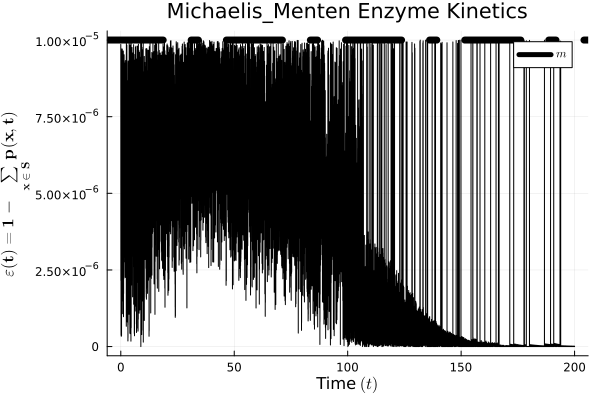

In [99]:
using LaTeXStrings
p=Plots.plot(T, m, label="",legend=false, color=:black)
hline!(p,[1e-5], label= L"$m$", legend=true,linestyle=:dashdot, linewidth=7, color=:black)
Plots.xlabel!(p,L"Time $(t)$")
Plots.ylabel!(p,L"$\mathbf{\epsilon(t) = 1 - \sum_{x \in S} p(x, t)}$")
Plots.title!(p, "Michaelis_Menten Enzyme Kinetics")
savefig("lv_err.pdf")
display(p)

In [17]:
sizes = []
for s in sol
    push!(sizes, length(s[1]))
end

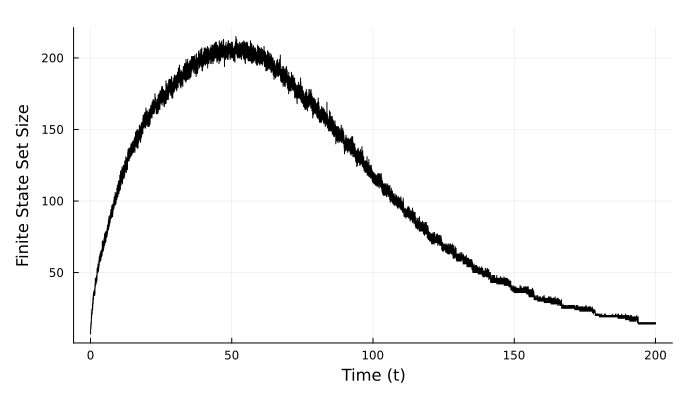

In [74]:
p=Plots.plot(T[2:end], sizes[2:end], legend=false, color=:black, size=(700, 400),  margin=5Plots.mm)
Plots.xlabel!("Time (t)")
Plots.ylabel!(L"Finite State Set Size")
savefig("mm_sizes.pdf")
display(p)